In [ ]:
# =======================
# Imports
# =======================
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import joblib
import random
import numpy as np
from sklearn.metrics import roc_auc_score, precision_score, recall_score, confusion_matrix, f1_score
from sklearn.feature_selection import SelectKBest, f_classif
import config

# --------------------------
# Set seeds for reproducibility
# --------------------------
SEED = config.SEED
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)


# =======================
# Custom Dataset
# =======================
class MultimodalDataset(Dataset):
    def __init__(self, clin_path, mrna_path, mut_path, labels_path):
        # Load preprocessed data
        self.clinical = joblib.load(clin_path).to_numpy().astype(float)
        self.mrna = joblib.load(mrna_path).to_numpy().astype(float)
        self.mutation = joblib.load(mut_path).to_numpy().astype(float)
        self.labels = joblib.load(labels_path).to_numpy().astype(float)
        print(self.clinical.shape)
        print(self.mrna.shape)
        print(self.mutation.shape)
                
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return (
            torch.tensor(self.clinical[idx], dtype=torch.float32),
            torch.tensor(self.mrna[idx], dtype=torch.float32),
            torch.tensor(self.mutation[idx], dtype=torch.float32),
            torch.tensor(self.labels[idx], dtype=torch.float32)
        )

# =======================
# Paths
# =======================
base_dir = "../preprocessed_data/stability_selection"

train_dataset = MultimodalDataset(
    f"{base_dir}/train/clinical.pkl",
    f"{base_dir}/train/mrna.pkl",
    f"{base_dir}/train/mutation.pkl",
    f"{base_dir}/train/labels.pkl"
)

val_dataset = MultimodalDataset(
    "../preprocessed_data/stability_selection/val/clinical.pkl",
    "../preprocessed_data/stability_selection/val/mrna.pkl",
    "../preprocessed_data/stability_selection/val/mutation.pkl",
    "../preprocessed_data/stability_selection/val/labels.pkl"
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

# =======================
# Simple Neural Network
# =======================
class SimpleMultimodalNet(nn.Module):
    def __init__(self, clin_dim, mrna_dim, mut_dim, hidden_dim=64):
        super().__init__()
        # Separate encoders for each modality
        self.clinical_fc = nn.Sequential(nn.Linear(clin_dim, hidden_dim), nn.ReLU())
        self.mrna_fc = nn.Sequential(nn.Linear(mrna_dim, hidden_dim), nn.ReLU())
        self.mut_fc = nn.Sequential(nn.Linear(mut_dim, hidden_dim), nn.ReLU())
        
        # Fusion layer
        self.fusion_fc = nn.Sequential(
            nn.Linear(hidden_dim * 3, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),  # Binary output
        )
        
    def forward(self, clin, mrna, mut):
        clin_emb = self.clinical_fc(clin)
        mrna_emb = self.mrna_fc(mrna)
        mut_emb = self.mut_fc(mut)
        
        # Concatenate embeddings
        fused = torch.cat([clin_emb, mrna_emb, mut_emb], dim=1)
        output = self.fusion_fc(fused)
        return output.squeeze()


# =======================
# Initialize Model
# =======================
# Use one batch to get dimensions
sample_batch = next(iter(train_loader))
clin_dim = sample_batch[0].shape[1]
mrna_dim = sample_batch[1].shape[1]
mut_dim = sample_batch[2].shape[1]
model = SimpleMultimodalNet(clin_dim, mrna_dim, mut_dim)

# =======================
# Loss and Optimizer
# =======================
# Compute pos_weight
num_pos = (train_dataset.labels == 1).sum()
num_neg = (train_dataset.labels == 0).sum()
pos_weight_val = num_neg / num_pos

# Convert to tensor and move to the same device as model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pos_weight = torch.tensor(pos_weight_val, dtype=torch.float32, device=device)

# Initialize loss
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# --------------------------
# Training loop with validation metrics
# --------------------------
num_epochs = 100
best_auroc = 0
patience = 10  # early stopping patience
counter = 0

for epoch in range(num_epochs):
    model.train()
    train_losses = []

    for clin, mrna, mut, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(clin, mrna, mut)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

    avg_train_loss = sum(train_losses) / len(train_losses)

    # --- Validation ---
    model.eval()
    val_losses = []
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for clin, mrna, mut, labels in val_loader:
            outputs = model(clin, mrna, mut)
            val_loss = criterion(outputs, labels)
            val_losses.append(val_loss.item())
            
            all_labels.append(labels)
            all_preds.append(torch.sigmoid(outputs))

    avg_val_loss = sum(val_losses) / len(val_losses)
    all_labels = torch.cat(all_labels)
    all_preds = torch.cat(all_preds)

    # Binarize predictions at 0.5 threshold
    pred_labels = (all_preds >= 0.5).float()

    val_auroc = roc_auc_score(all_labels.numpy(), all_preds.numpy())
    val_precision = precision_score(all_labels.numpy(), pred_labels.numpy(), zero_division=0)
    val_recall = recall_score(all_labels.numpy(), pred_labels.numpy(), zero_division=0)
    val_f1 = f1_score(all_labels.numpy(), pred_labels.numpy(), zero_division=0)

    print(f"Epoch {epoch+1} - "
          f"Train Loss: {avg_train_loss:.4f}, "
          f"Val Loss: {avg_val_loss:.4f}, "
          f"AUROC: {val_auroc:.4f}, "
          f"Precision: {val_precision:.4f}, "
          f"Recall: {val_recall:.4f}, "
          f"F1: {val_f1:.4f}")

    # --- Early stopping based on AUROC ---
    if val_auroc >= best_auroc:
        best_auroc = val_auroc
        counter = 0
        # Optionally save best model
        torch.save(model.state_dict(), "best_model.pth")
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping at epoch {epoch+1} with patience of {patience}")
            break



(316, 31)
(316, 2195)
(316, 17650)
(68, 31)
(68, 2195)
(68, 17650)
Epoch 1 - Train Loss: 39.1125, Val Loss: 23.0530, AUROC: 0.5727, Precision: 0.1940, Recall: 1.0000, F1: 0.3250
Epoch 2 - Train Loss: 17.0999, Val Loss: 11.6011, AUROC: 0.6266, Precision: 0.0000, Recall: 0.0000, F1: 0.0000
Epoch 3 - Train Loss: 9.4029, Val Loss: 5.9809, AUROC: 0.6168, Precision: 0.2157, Recall: 0.8462, F1: 0.3438
Epoch 4 - Train Loss: 7.4984, Val Loss: 3.4587, AUROC: 0.6294, Precision: 0.2105, Recall: 0.3077, F1: 0.2500
Epoch 5 - Train Loss: 7.1474, Val Loss: 3.6780, AUROC: 0.6308, Precision: 0.1875, Recall: 0.2308, F1: 0.2069
Epoch 6 - Train Loss: 7.2054, Val Loss: 4.4620, AUROC: 0.6280, Precision: 0.2439, Recall: 0.7692, F1: 0.3704
Epoch 7 - Train Loss: 6.5590, Val Loss: 4.6477, AUROC: 0.6357, Precision: 0.2500, Recall: 0.8462, F1: 0.3860
Epoch 8 - Train Loss: 6.3434, Val Loss: 3.1213, AUROC: 0.6476, Precision: 0.3103, Recall: 0.6923, F1: 0.4286
Epoch 9 - Train Loss: 5.1951, Val Loss: 3.5193, AUROC: 0.

In [ ]:
model.load_state_dict(torch.load("best_model.pth"))
model.eval()
all_labels = []
all_probs = []

with torch.no_grad():
    for clin, mrna, mut, labels in val_loader:
        outputs = model(clin, mrna, mut)
        probs = torch.sigmoid(outputs)
        
        all_labels.append(labels)
        all_probs.append(probs)

# Concatenate batches
all_labels = torch.cat(all_labels).cpu().numpy()
all_probs = torch.cat(all_probs).cpu().numpy()

# --- Find optimal threshold based on F1 score ---
thresholds = np.linspace(0, 1, 101)  # 0.00, 0.01, ..., 1.00
f1_scores = []

for t in thresholds:
    preds = (all_probs >= t).astype(float)
    f1 = f1_score(all_labels, preds)
    f1_scores.append(f1)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
print(f"Optimal threshold for F1: {best_threshold:.2f}, F1 score: {f1_scores[best_idx]:.4f}")

# Use optimal threshold for predictions
preds = (all_probs >= best_threshold).astype(float)

# Metrics
val_loss = criterion(torch.tensor(all_probs), torch.tensor(all_labels)).item()
precision = precision_score(all_labels, preds)
recall = recall_score(all_labels, preds)
auroc = roc_auc_score(all_labels, all_probs)
cm = confusion_matrix(all_labels, preds)

# Unpack confusion matrix
tn, fp, fn, tp = cm.ravel()

print(f"Validation Loss: {val_loss:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"AUROC: {auroc:.4f}")
print("Confusion Matrix:")
print(f"True Negatives: {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives: {tp}")

Optimal threshold for F1: 0.11, F1 score: 0.5882
Validation Loss: 1.0614
Precision: 0.4762
Recall: 0.7692
AUROC: 0.8210
Confusion Matrix:
True Negatives: 44
False Positives: 11
False Negatives: 3
True Positives: 10


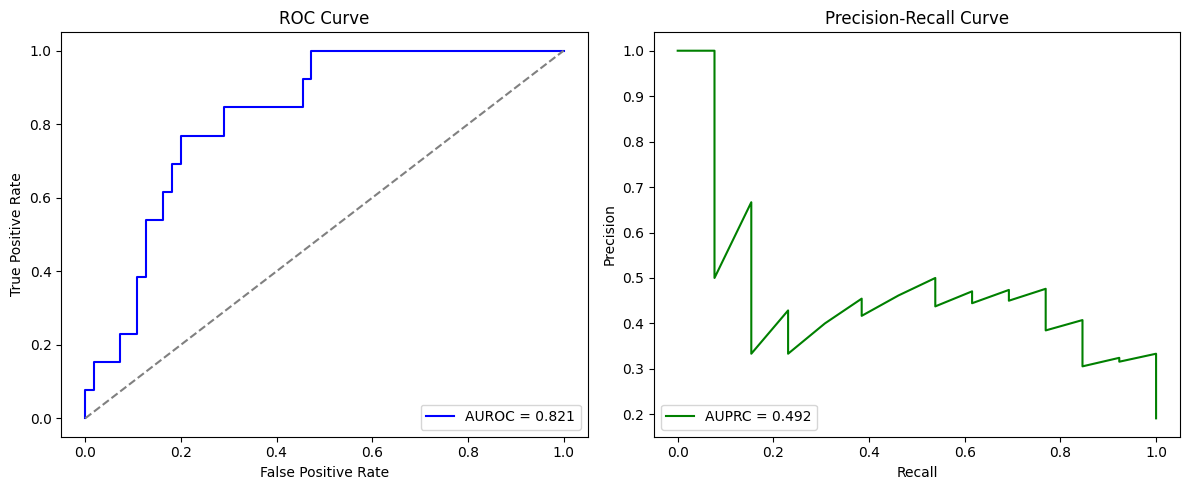

In [3]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

def plot_metrics(y_true, y_scores):
    y_true = y_true.numpy()
    y_scores = y_scores.numpy()
    
    # ---------- AUROC ----------
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(12,5))
    
    plt.subplot(1, 2, 1)
    plt.plot(fpr, tpr, color='blue', label=f'AUROC = {roc_auc:.3f}')
    plt.plot([0,1], [0,1], color='gray', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')
    
    # ----------  AUPRC ----------
    precision, recall, _ = precision_recall_curve(y_true, y_scores)
    ap_score = average_precision_score(y_true, y_scores)
    
    plt.subplot(1, 2, 2)
    plt.plot(recall, precision, color='green', label=f'AUPRC = {ap_score:.3f}')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend(loc='lower left')
    
    plt.tight_layout()
    plt.show()

model.eval()
all_labels = []
all_outputs = []
with torch.no_grad():
    for clin, mrna, mut, labels in val_loader:
        outputs = model(clin, mrna, mut)
        all_outputs.append(torch.sigmoid(outputs))
        all_labels.append(labels)

all_labels = torch.cat(all_labels)
all_outputs = torch.cat(all_outputs)

plot_metrics(all_labels, all_outputs)
